# Visualize Predictions: Baseline vs Improved Models + HQNN Fusion

Notebook này hiển thị so sánh giữa Ground Truth và các dự đoán từ:

## Baseline Models:
- YOLOv8n
- YOLOv9n
- YOLOv10n
- YOLOv11n
- YOLOv12n (Original)
- YOLOv26n

## Improved Models (Cải tiến):
- YOLOv12n (Before Augmentation)
- YOLOv12n (After Augmentation)
- YOLOv12n (DySample)
- YOLOv12n (CARAFE)
- YOLOv12n + HQNN (Hybrid Quantum Fusion)

## 1. Cài đặt thư viện

In [887]:
import sys
import subprocess

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *pkgs])

required_packages = ["ultralytics", "opencv-python", "matplotlib", "pennylane"]
pip_install(*required_packages)


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


## 2. Imports & Cấu hình

In [888]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO
import torch
import torch.nn as nn
import torch.nn.functional as F
import pennylane as qml

# Cấu hình đường dẫn
BASE_DIR_BEFORE = Path("/Users/mac/Detect_Drill_Bit/Models_Before_Handle_Data")
BASE_DIR_AFTER = Path("/Users/mac/Detect_Drill_Bit/Models_After_Handle_Data")
DATA_DIR = Path("/Users/mac/Detect_Drill_Bit/data/data_convert_yolo_format")

# Class names
CLASS_NAMES = ["Broken", "Chipped", "Scratched", "Severe_Rust", "Tip_Wear"]
NUM_CLASSES = len(CLASS_NAMES)

# Colors cho từng class
COLORS = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

# Device
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cpu


## 2.1. Đăng ký Custom Modules (DySample, CARAFE)

In [889]:
from ultralytics.nn import modules, tasks

# Định nghĩa DySample
class DySample(nn.Module):
    """Lightweight Dynamic Upsampling"""
    def __init__(self, c1, scale_factor=2, groups=2):
        super().__init__()
        self.scale_factor = scale_factor
        self.groups = groups
        self.offset = nn.Conv2d(c1, 2 * groups * scale_factor * scale_factor, kernel_size=1)
        nn.init.normal_(self.offset.weight, std=0.001)
        nn.init.constant_(self.offset.bias, 0)

    def forward(self, x):
        B, C, H, W = x.shape
        s, g = self.scale_factor, self.groups
        offset = self.offset(x)
        offset = F.pixel_shuffle(offset, s).to(x.dtype)
        offset = offset.view(B, 2, g, H * s, W * s)
        yy, xx = torch.meshgrid(torch.arange(H * s, device=x.device), torch.arange(W * s, device=x.device), indexing='ij')
        grid = torch.stack((xx, yy), dim=0).to(x.dtype)
        grid[0] = 2.0 * grid[0] / max(W * s - 1, 1) - 1.0
        grid[1] = 2.0 * grid[1] / max(H * s - 1, 1) - 1.0
        grid = grid.unsqueeze(0).unsqueeze(2) + offset / max(H * s, W * s)
        x = x.view(B, g, C // g, H, W)
        outputs = []
        for i in range(g):
            sampled = F.grid_sample(x[:, i], grid[:, :, i].permute(0, 2, 3, 1), mode='bilinear', padding_mode='border', align_corners=False)
            outputs.append(sampled)
        return torch.cat(outputs, dim=1)

# Định nghĩa CARAFE
class CARAFE(nn.Module):
    def __init__(self, c1, scale_factor=2, k_encoder=3, up_kernel=3):
        super(CARAFE, self).__init__()
        self.scale_factor = scale_factor
        self.up_kernel = up_kernel
        self.k_encoder = k_encoder
        self.down = nn.Conv2d(c1, c1 // 4, 1)
        self.encoder = nn.Conv2d(c1 // 4, self.up_kernel ** 2 * self.scale_factor ** 2, self.k_encoder, padding=self.k_encoder // 2)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        N, C, H, W = x.size()
        kernel_tensor = self.softmax(F.pixel_shuffle(self.encoder(self.down(x)), self.scale_factor))
        x = F.unfold(F.interpolate(x, scale_factor=self.scale_factor, mode='nearest'), self.up_kernel, padding=self.up_kernel // 2)
        x = x.view(N, C, self.up_kernel**2, -1)
        kernel_tensor = kernel_tensor.view(N, 1, self.up_kernel**2, -1)
        out = (x * kernel_tensor).sum(dim=2).view(N, C, H * self.scale_factor, W * self.scale_factor)
        return out

# Đăng ký modules
setattr(modules, 'DySample', DySample)
setattr(tasks, 'DySample', DySample)
setattr(modules, 'CARAFE', CARAFE)
setattr(tasks, 'CARAFE', CARAFE)

print("✓ Custom modules registered successfully")

✓ Custom modules registered successfully


## 3. Load Baseline Models

In [890]:
# Đường dẫn đến các baseline model
BASELINE_PATHS = {
    "YOLOv8n": BASE_DIR_BEFORE / "yolo_v8/results/runs/detect/train/weights/best.pt",
    "YOLOv9n": BASE_DIR_BEFORE / "yolo_v9/results/runs/detect/train/weights/best.pt",
    "YOLOv10n": BASE_DIR_BEFORE / "yolo_v10/results/runs/detect/train/weights/best.pt",
    "YOLOv11n": BASE_DIR_BEFORE / "yolo_v11/results/runs/detect/train/weights/best.pt",
    "YOLOv12n (Original)": BASE_DIR_BEFORE / "yolo_v12/results/runs/detect/train/weights/best.pt",
    "YOLOv26n": BASE_DIR_BEFORE / "yolo_v26/results/runs/detect/train/weights/best.pt"
}

# Load baseline models
baseline_models = {}
for name, path in BASELINE_PATHS.items():
    if path.exists():
        print(f"Loading {name} from {path}")
        try:
            baseline_models[name] = YOLO(str(path))
            print(f"  ✓ Loaded successfully")
        except Exception as e:
            print(f"  ✗ Error loading: {e}")
    else:
        print(f"  ✗ Not found: {path}")

print(f"\nTotal baseline models loaded: {len(baseline_models)}")

Loading YOLOv8n from /Users/mac/Detect_Drill_Bit/Models_Before_Handle_Data/yolo_v8/results/runs/detect/train/weights/best.pt
  ✓ Loaded successfully
Loading YOLOv9n from /Users/mac/Detect_Drill_Bit/Models_Before_Handle_Data/yolo_v9/results/runs/detect/train/weights/best.pt
  ✓ Loaded successfully
Loading YOLOv10n from /Users/mac/Detect_Drill_Bit/Models_Before_Handle_Data/yolo_v10/results/runs/detect/train/weights/best.pt
  ✓ Loaded successfully
Loading YOLOv11n from /Users/mac/Detect_Drill_Bit/Models_Before_Handle_Data/yolo_v11/results/runs/detect/train/weights/best.pt
  ✓ Loaded successfully
Loading YOLOv12n (Original) from /Users/mac/Detect_Drill_Bit/Models_Before_Handle_Data/yolo_v12/results/runs/detect/train/weights/best.pt
  ✓ Loaded successfully
Loading YOLOv26n from /Users/mac/Detect_Drill_Bit/Models_Before_Handle_Data/yolo_v26/results/runs/detect/train/weights/best.pt
  ✓ Loaded successfully

Total baseline models loaded: 6


## 4. Load Improved Models

In [891]:
# Đường dẫn đến các improved model (HQNN sử dụng fusion riêng, không load trực tiếp ở đây)
IMPROVED_PATHS = {
    "YOLOv12n (Before Aug)": BASE_DIR_AFTER / "yolov12_before_aug/results/runs/detect/train/weights/best.pt",
    "YOLOv12n (After Aug)": BASE_DIR_AFTER / "yolov12_after_aug/results/runs/detect/train/weights/best.pt",
    "YOLOv12n (DySample)": BASE_DIR_AFTER / "yolov12_dysample/best.pt",
    "YOLOv12n (CARAFE)": BASE_DIR_AFTER / "yolov12_carafe/best.pt"
}

# Load improved models
improved_models = {}
for name, path in IMPROVED_PATHS.items():
    if path.exists():
        print(f"Loading {name} from {path}")
        try:
            improved_models[name] = YOLO(str(path))
            print(f"  ✓ Loaded successfully")
        except Exception as e:
            print(f"  ✗ Error loading: {e}")
    else:
        print(f"  ✗ Not found: {path}")

print(f"\nTotal improved models loaded: {len(improved_models)}")

Loading YOLOv12n (Before Aug) from /Users/mac/Detect_Drill_Bit/Models_After_Handle_Data/yolov12_before_aug/results/runs/detect/train/weights/best.pt
  ✓ Loaded successfully
Loading YOLOv12n (After Aug) from /Users/mac/Detect_Drill_Bit/Models_After_Handle_Data/yolov12_after_aug/results/runs/detect/train/weights/best.pt
  ✓ Loaded successfully
Loading YOLOv12n (DySample) from /Users/mac/Detect_Drill_Bit/Models_After_Handle_Data/yolov12_dysample/best.pt
  ✓ Loaded successfully
Loading YOLOv12n (CARAFE) from /Users/mac/Detect_Drill_Bit/Models_After_Handle_Data/yolov12_carafe/best.pt
  ✓ Loaded successfully

Total improved models loaded: 4


## 5. Load HQNN Model

In [892]:
# HQNN Configuration
N_QUBITS = 4
N_LAYERS = 3
HQNN_IMG_SIZE = 240

# Quantum device
quantum_device = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(quantum_device, interface="torch")
def quantum_circuit(inputs, weights):
    for i in range(N_QUBITS):
        qml.Hadamard(wires=i)
    for i in range(N_QUBITS):
        qml.RY(inputs[..., i], wires=i)
    for layer in range(N_LAYERS):
        for i in range(N_QUBITS - 1):
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[N_QUBITS - 1, 0])
        for i in range(N_QUBITS):
            qml.RY(weights[layer, i], wires=i)
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

# HQNN Classifier Architecture
class HQNNClassifier(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1), nn.BatchNorm2d(16), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
        )
        self.pool = nn.AdaptiveAvgPool2d((2, 2))
        self.fc_encode = nn.Sequential(nn.Linear(64 * 2 * 2, N_QUBITS), nn.Tanh())
        weight_shapes = {"weights": (N_LAYERS, N_QUBITS)}
        self.quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)
        self.quantum_fc = nn.Sequential(nn.Linear(N_QUBITS, N_QUBITS), nn.Tanh())
        self.classifier = nn.Linear(N_QUBITS, num_classes)

    def forward(self, x):
        x = self.pool(self.features(x))
        x = (self.fc_encode(torch.flatten(x, 1)) + 1.0) * (torch.pi / 2.0)
        x = self.classifier(self.quantum_fc(self.quantum_layer(x)))
        return x

    def predict_proba(self, x):
        return F.softmax(self.forward(x), dim=1)

# Load HQNN weights
HQNN_WEIGHTS = BASE_DIR_AFTER / "yolov12_hybrid_quantum/quantum_/hqnn_best_2.pt"
YOLO_FOR_HQNN = BASE_DIR_AFTER / "yolov12_after_aug/results/runs/detect/train/weights/best.pt"

hqnn_model = None
yolo_for_hqnn = None

if HQNN_WEIGHTS.exists() and YOLO_FOR_HQNN.exists():
    print(f"Loading HQNN from: {HQNN_WEIGHTS}")
    hqnn_model = HQNNClassifier(num_classes=NUM_CLASSES).to(DEVICE)
    checkpoint = torch.load(str(HQNN_WEIGHTS), map_location=DEVICE, weights_only=False)
    if isinstance(checkpoint, dict) and "model_state" in checkpoint:
        hqnn_model.load_state_dict(checkpoint["model_state"])
    elif isinstance(checkpoint, dict):
        hqnn_model.load_state_dict(checkpoint)
    else:
        hqnn_model = checkpoint.to(DEVICE)
    hqnn_model.eval()
    print("  ✓ HQNN loaded successfully")
    
    print(f"Loading YOLO for HQNN from: {YOLO_FOR_HQNN}")
    yolo_for_hqnn = YOLO(str(YOLO_FOR_HQNN))
    print("  ✓ YOLO for HQNN loaded successfully")
else:
    print("⚠️ HQNN weights or YOLO for HQNN not found, skipping HQNN fusion")

Loading HQNN from: /Users/mac/Detect_Drill_Bit/Models_After_Handle_Data/yolov12_hybrid_quantum/quantum_/hqnn_best_2.pt
  ✓ HQNN loaded successfully
Loading YOLO for HQNN from: /Users/mac/Detect_Drill_Bit/Models_After_Handle_Data/yolov12_after_aug/results/runs/detect/train/weights/best.pt
  ✓ YOLO for HQNN loaded successfully


## 5.1. HQNN Fusion Function

In [893]:
def preprocess_roi(crop_bgr):
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    crop_resized = cv2.resize(crop_rgb, (HQNN_IMG_SIZE, HQNN_IMG_SIZE))
    crop_norm = crop_resized.astype(np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    crop_norm = (crop_norm - mean) / std
    tensor = torch.from_numpy(crop_norm.transpose(2, 0, 1)).unsqueeze(0).float()
    return tensor.to(DEVICE)

def predict_q_yolo_fusion(image_path, conf_thresh=0.25):
    if hqnn_model is None or yolo_for_hqnn is None:
        return [], None
    
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        return [], None
    h, w = img_bgr.shape[:2]

    results = yolo_for_hqnn(str(image_path), conf=conf_thresh, device=DEVICE, verbose=False)
    detections = []

    for result in results:
        if result.boxes is None or len(result.boxes) == 0:
            continue
        boxes_xyxy = result.boxes.xyxy.detach().cpu().numpy()
        yolo_confs = result.boxes.conf.detach().cpu().numpy()
        yolo_cls_id = result.boxes.cls.detach().cpu().numpy().astype(int)

        for xyxy, yolo_conf, yolo_cid in zip(boxes_xyxy, yolo_confs, yolo_cls_id):
            x1, y1, x2, y2 = map(int, xyxy)
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w, x2), min(h, y2)
            if x2 <= x1 or y2 <= y1:
                continue

            crop = img_bgr[y1:y2, x1:x2]
            roi_tensor = preprocess_roi(crop)
            with torch.no_grad():
                logits = hqnn_model(roi_tensor)
                p_quantum = F.softmax(logits, dim=1).squeeze(0)

            p_yolo = torch.zeros(NUM_CLASSES, device=p_quantum.device)
            p_yolo[yolo_cid] = float(yolo_conf)
            yolo_conf = float(yolo_conf)
            hqnn_conf = float(p_quantum.max().item())

            # Adaptive fusion
            if yolo_conf >= 0.85:
                alpha = 1.0
            elif yolo_conf >= 0.7:
                alpha = 0.98
            elif yolo_cid == int(p_quantum.argmax().item()) and hqnn_conf >= 0.85:
                alpha = 0.9
            else:
                alpha = 1.0
            
            p_final = alpha * p_yolo + (1 - alpha) * p_quantum
            final_cls = int(p_final.argmax().item())
            final_conf = float(p_final[final_cls].item())

            detections.append({
                "bbox": (x1, y1, x2, y2),
                "cls_id": final_cls,
                "cls_name": CLASS_NAMES[final_cls],
                "conf": final_conf
            })

    return detections, img_bgr

## 6. Hàm đọc Ground Truth

In [894]:
def load_ground_truth(label_path, img_w, img_h):
    """Đọc file label YOLO format và chuyển sang tọa độ tuyệt đối."""
    boxes = []
    if not label_path.exists():
        return boxes
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls_id = int(parts[0])
            cx, cy, bw, bh = map(float, parts[1:5])
            x1 = int((cx - bw / 2) * img_w)
            y1 = int((cy - bh / 2) * img_h)
            x2 = int((cx + bw / 2) * img_w)
            y2 = int((cy + bh / 2) * img_h)
            boxes.append({"cls_id": cls_id, "cls_name": CLASS_NAMES[cls_id], "bbox": (x1, y1, x2, y2)})
    return boxes

In [895]:
def predict_q_yolo_fusion(yolo_model, image_path, conf_thresh=0.25):
    """HQNN fusion với YOLO model được truyền vào - trả về chi tiết như notebook gốc."""
    if hqnn_model is None:
        return [], None
    
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        return [], None
    h, w = img_bgr.shape[:2]

    results = yolo_model(str(image_path), conf=conf_thresh, device=DEVICE, verbose=False)
    detections = []

    for result in results:
        if result.boxes is None or len(result.boxes) == 0:
            continue
        boxes_xyxy = result.boxes.xyxy.detach().cpu().numpy()
        yolo_confs = result.boxes.conf.detach().cpu().numpy()
        yolo_cls_id = result.boxes.cls.detach().cpu().numpy().astype(int)

        for xyxy, yolo_conf, yolo_cid in zip(boxes_xyxy, yolo_confs, yolo_cls_id):
            x1, y1, x2, y2 = map(int, xyxy)
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w, x2), min(h, y2)
            if x2 <= x1 or y2 <= y1:
                continue

            crop = img_bgr[y1:y2, x1:x2]
            roi_tensor = preprocess_roi(crop)
            with torch.no_grad():
                logits = hqnn_model(roi_tensor)
                p_quantum = F.softmax(logits, dim=1).squeeze(0)

            p_yolo = torch.zeros(NUM_CLASSES, device=p_quantum.device)
            p_yolo[yolo_cid] = float(yolo_conf)
            yolo_conf = float(yolo_conf)
            hqnn_conf = float(p_quantum.max().item())

            # Adaptive fusion
            if yolo_conf >= 0.85:
                alpha = 1.0
            elif yolo_conf >= 0.7:
                alpha = 0.98
            elif yolo_cid == int(p_quantum.argmax().item()) and hqnn_conf >= 0.85:
                alpha = 0.9
            else:
                alpha = 1.0
            
            p_final = alpha * p_yolo + (1 - alpha) * p_quantum
            final_cls = int(p_final.argmax().item())
            final_conf = float(p_final[final_cls].item())

            detections.append({
                "bbox": (x1, y1, x2, y2),
                "yolo_cls": yolo_cid,
                "yolo_conf": yolo_conf,
                "p_yolo": p_yolo.detach().cpu().numpy(),
                "p_quantum": p_quantum.detach().cpu().numpy(),
                "p_final": p_final.detach().cpu().numpy(),
                "final_cls": final_cls,
                "final_conf": final_conf,
            })

    return detections, img_bgr

In [896]:
def visualize_predictions(img_path, gt_boxes, model_predictions, title="Predictions"):
    """Hiển thị ảnh với ground truth và predictions từ các model."""
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        print(f"Cannot read image: {img_path}")
        return
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    num_models = len(model_predictions)
    cols = 3
    rows = (num_models + 2) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
    fig.suptitle(f"{title}\nImage: {img_path.name}", fontsize=14, fontweight='bold')
    
    if num_models == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    # Ground Truth
    ax = axes[0]
    ax.imshow(img_rgb)
    ax.set_title("Ground Truth", fontsize=12, fontweight='bold', color='green')
    for gt in gt_boxes:
        x1, y1, x2, y2 = gt["bbox"]
        color = COLORS[gt["cls_id"]][:3]
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=3, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1-5, gt["cls_name"], color=color, fontsize=10, bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.7))
    
    # Model predictions
    for idx, (model_name, preds) in enumerate(model_predictions.items()):
        ax = axes[idx + 1]
        ax.imshow(img_rgb)
        ax.set_title(f"{model_name}\nDetections: {len(preds)}", fontsize=11, fontweight='bold')
        for pred in preds:
            x1, y1, x2, y2 = pred["bbox"]
            color = COLORS[pred["cls_id"]][:3]
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1-5, f"{pred['cls_name']} {pred['conf']:.2f}", color=color, fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.5))
    
    for idx in range(num_models + 1, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

## 8. Chạy inference - Baseline Models

In [897]:
test_img_dir = DATA_DIR / "test/Bright_Field/images"
test_label_dir = DATA_DIR / "test/Bright_Field/labels"
img_files = list(test_img_dir.glob("*.jpg")) + list(test_img_dir.glob("*.png"))

if not img_files:
    print("Không tìm thấy ảnh test!")
else:
    img_path = img_files[200]
    print(f"Đang xử lý ảnh: {img_path.name}")
    
    label_path = test_label_dir / (img_path.stem + ".txt")
    img_bgr = cv2.imread(str(img_path))
    h, w = img_bgr.shape[:2]
    gt_boxes = load_ground_truth(label_path, w, h)
    print(f"Ground Truth: {len(gt_boxes)} objects")
    
    baseline_predictions = {}
    for model_name, model in baseline_models.items():
        results = model(str(img_path), conf=0.25, device=DEVICE, verbose=False)
        preds = []
        for result in results:
            if result.boxes is None or len(result.boxes) == 0:
                continue
            boxes_xyxy = result.boxes.xyxy.detach().cpu().numpy()
            confs = result.boxes.conf.detach().cpu().numpy()
            cls_ids = result.boxes.cls.detach().cpu().numpy().astype(int)
            for xyxy, conf, cls_id in zip(boxes_xyxy, confs, cls_ids):
                x1, y1, x2, y2 = map(int, xyxy)
                preds.append({"bbox": (x1, y1, x2, y2), "cls_id": int(cls_id), "cls_name": CLASS_NAMES[int(cls_id)], "conf": float(conf)})
        baseline_predictions[model_name] = preds
        print(f"  {model_name}: {len(preds)} detections")

Đang xử lý ảnh: S242_Image__2025-11-11__11-45-30_bright_3_crop_5_jpg.rf.aed960434f5ee19e22aecb2c5238c7e8.jpg
Ground Truth: 3 objects
  YOLOv8n: 3 detections
  YOLOv9n: 3 detections
  YOLOv10n: 2 detections
  YOLOv11n: 3 detections
  YOLOv12n (Original): 1 detections
  YOLOv26n: 1 detections


In [898]:
def visualize_predictions(img_path, gt_boxes, model_predictions, title="Predictions"):
    """Hiển thị ảnh với ground truth và predictions từ các model."""
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        print(f"Cannot read image: {img_path}")
        return
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    num_models = len(model_predictions)
    total_plots = num_models + 1  # +1 for Ground Truth
    cols = 3
    rows = (total_plots + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
    fig.suptitle(f"{title}\nImage: {img_path.name}", fontsize=14, fontweight='bold')
    
    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1 or cols == 1:
        axes = axes.reshape(rows, cols)
    axes = axes.flatten()
    
    # Ground Truth
    ax = axes[0]
    ax.imshow(img_rgb)
    ax.set_title("Ground Truth", fontsize=12, fontweight='bold', color='green')
    for gt in gt_boxes:
        x1, y1, x2, y2 = gt["bbox"]
        color = COLORS[gt["cls_id"]][:3]
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=3, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1-5, gt["cls_name"], color=color, fontsize=10, bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.7))
    
    # Model predictions
    for idx, (model_name, preds) in enumerate(model_predictions.items()):
        if idx + 1 >= len(axes):
            break
        ax = axes[idx + 1]
        ax.imshow(img_rgb)
        ax.set_title(f"{model_name}\nDetections: {len(preds)}", fontsize=11, fontweight='bold')
        for pred in preds:
            x1, y1, x2, y2 = pred["bbox"]
            color = COLORS[pred["cls_id"]][:3]
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1-5, f"{pred['cls_name']} {pred['conf']:.2f}", color=color, fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.5))
    
    for idx in range(total_plots, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

def visualize_hqnn_fusion_details(yolo_model, img_path, conf_thresh=0.25):
    """Hiển thị chi tiết HQNN fusion giống notebook gốc (YOLO vs Quantum details)."""
    detections, img_bgr = predict_q_yolo_fusion(yolo_model, img_path, conf_thresh=conf_thresh)
    if img_bgr is None:
        return
    
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    ax.imshow(img_rgb)
    ax.set_title(f"QEDL-YOLOv12: Average Fusion (YOLO vs Quantum Details)\nImage: {img_path.name}", fontsize=14, fontweight='bold')
    
    print(f"\n📸 --- Ảnh: {img_path.name} ({len(detections)} Detections) ---")
    for b_idx, det in enumerate(detections, 1):
        x1, y1, x2, y2 = det["bbox"]
        fc = det["final_cls"]
        conf = det["final_conf"]
        color = COLORS[fc % len(COLORS)][:3]
        
        p_yolo_val = det["yolo_conf"]
        p_quant_val = det["p_quantum"][fc]
        yolo_name = CLASS_NAMES[det["yolo_cls"]]
        final_name = CLASS_NAMES[fc]
        
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2.5, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        
        if det["yolo_cls"] != fc:
            tag = f"{final_name}:{conf:.2f} [YOLO:{yolo_name}({p_yolo_val:.2f}) | Q:{p_quant_val:.2f}]"
        else:
            tag = f"{final_name}:{conf:.2f} [YOLO:{p_yolo_val:.2f} | Q:{p_quant_val:.2f}]"
        
        ax.text(x1, max(0, y1 - 8), tag, bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.85),
                fontsize=8, color="white", fontweight="bold")
        
        print(f"  Box {b_idx}: Final={final_name}({conf:.2f}) | YOLO={yolo_name}({p_yolo_val:.2f}) | Quantum_P_q({final_name})={p_quant_val:.2f}")
    
    ax.axis('off')
    plt.tight_layout()
    plt.show()

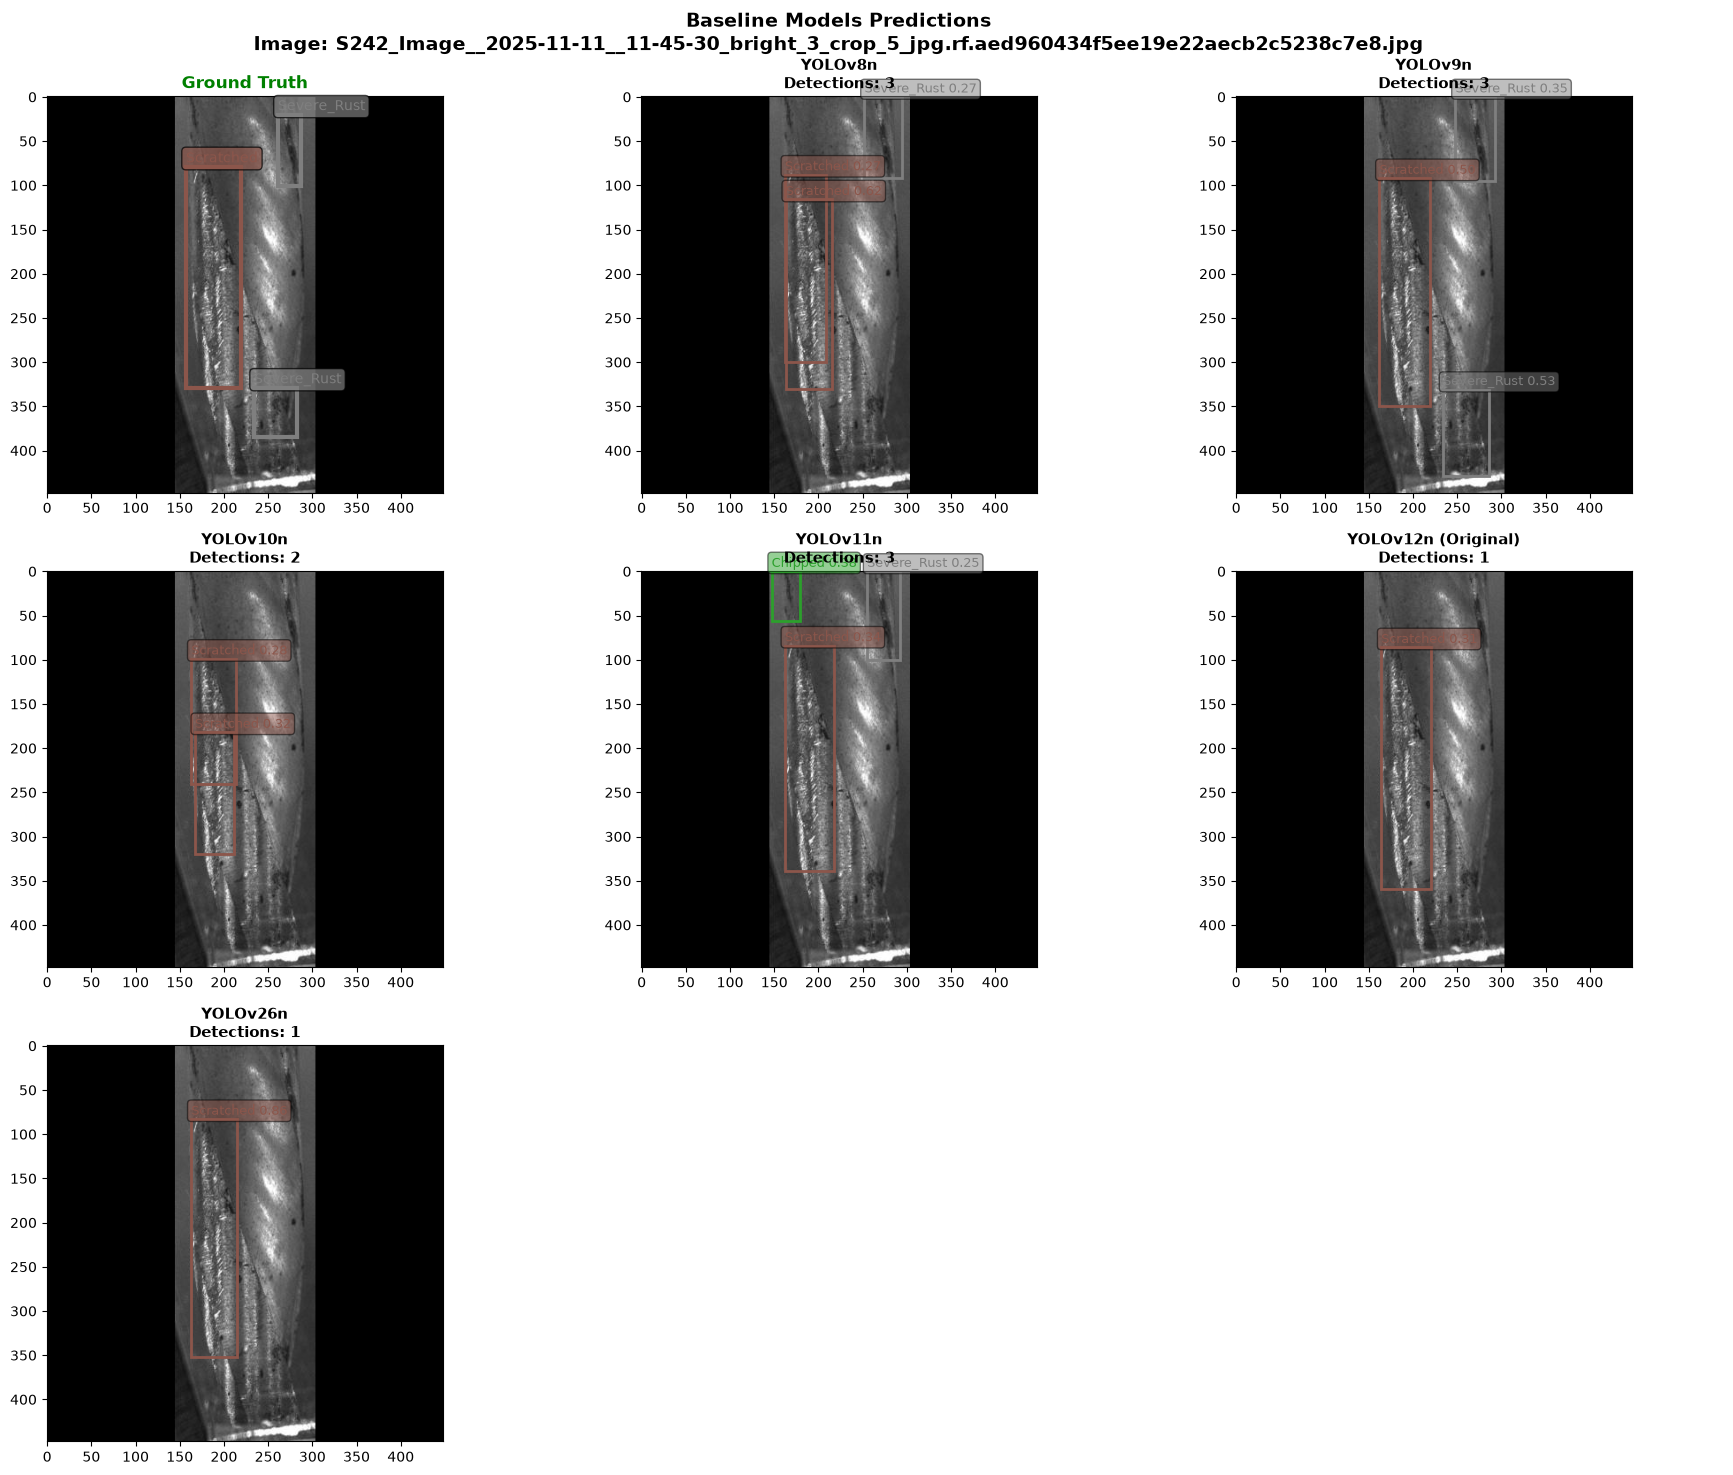

In [899]:
visualize_predictions(img_path, gt_boxes, baseline_predictions, title="Baseline Models Predictions")

## 9. Chạy inference - Improved Models

In [900]:
improved_predictions = {}
for model_name, model in improved_models.items():
    results = model(str(img_path), conf=0.25, device=DEVICE, verbose=False)
    preds = []
    for result in results:
        if result.boxes is None or len(result.boxes) == 0:
            continue
        boxes_xyxy = result.boxes.xyxy.detach().cpu().numpy()
        confs = result.boxes.conf.detach().cpu().numpy()
        cls_ids = result.boxes.cls.detach().cpu().numpy().astype(int)
        for xyxy, conf, cls_id in zip(boxes_xyxy, confs, cls_ids):
            x1, y1, x2, y2 = map(int, xyxy)
            preds.append({"bbox": (x1, y1, x2, y2), "cls_id": int(cls_id), "cls_name": CLASS_NAMES[int(cls_id)], "conf": float(conf)})
    improved_predictions[model_name] = preds
    print(f"  {model_name}: {len(preds)} detections")

# YOLOv12n + HQNN Fusion (same logic as hybrid_quantum.ipynb)
if hqnn_model is not None and yolo_for_hqnn is not None:
    print("  YOLOv12n + HQNN: running fusion...")
    detections_hqnn, _ = predict_q_yolo_fusion(yolo_for_hqnn, img_path, conf_thresh=0.25)
    hqnn_preds = []
    for det in detections_hqnn:
        hqnn_preds.append({
            "bbox": det["bbox"],
            "cls_id": det["final_cls"],
            "cls_name": CLASS_NAMES[det["final_cls"]],
            "conf": det["final_conf"]
        })
    improved_predictions["YOLOv12n + HQNN"] = hqnn_preds
    print(f"  YOLOv12n + HQNN: {len(hqnn_preds)} detections")
else:
    print("  YOLOv12n + HQNN: skipped (HQNN model not loaded)")


  YOLOv12n (Before Aug): 3 detections
  YOLOv12n (After Aug): 3 detections
  YOLOv12n (DySample): 3 detections
  YOLOv12n (CARAFE): 4 detections
  YOLOv12n + HQNN: running fusion...
  YOLOv12n + HQNN: 3 detections


In [ ]:
# Chọn ảnh - thay đổi số index để chọn ảnh khác
img_index = 108  # Thay đổi số này (0, 1, 2, ...)
test_img_dir = DATA_DIR / "test/Bright_Field/images"
img_files = list(test_img_dir.glob("*.jpg")) + list(test_img_dir.glob("*.png"))
img_path = img_files[img_index]
print(f"Đã chọn ảnh: {img_path.name}")

Đã chọn ảnh: S77_Image__2025-09-08__16-11-31_bright_4_crop_4_jpg.rf.b2e83cafde6ff130cf6405a6187dfa28.jpg


Ground Truth: 3 objects
  YOLOv8n: 1 detections
  YOLOv9n: 2 detections
  YOLOv10n: 1 detections
  YOLOv11n: 2 detections
  YOLOv12n (Original): 3 detections
  YOLOv26n: 1 detections
  YOLOv12n (Before Aug): 3 detections
  YOLOv12n (After Aug): 3 detections
  YOLOv12n (DySample): 4 detections
  YOLOv12n (CARAFE): 4 detections
  YOLOv12n + HQNN: running fusion...
  YOLOv12n + HQNN: 3 detections


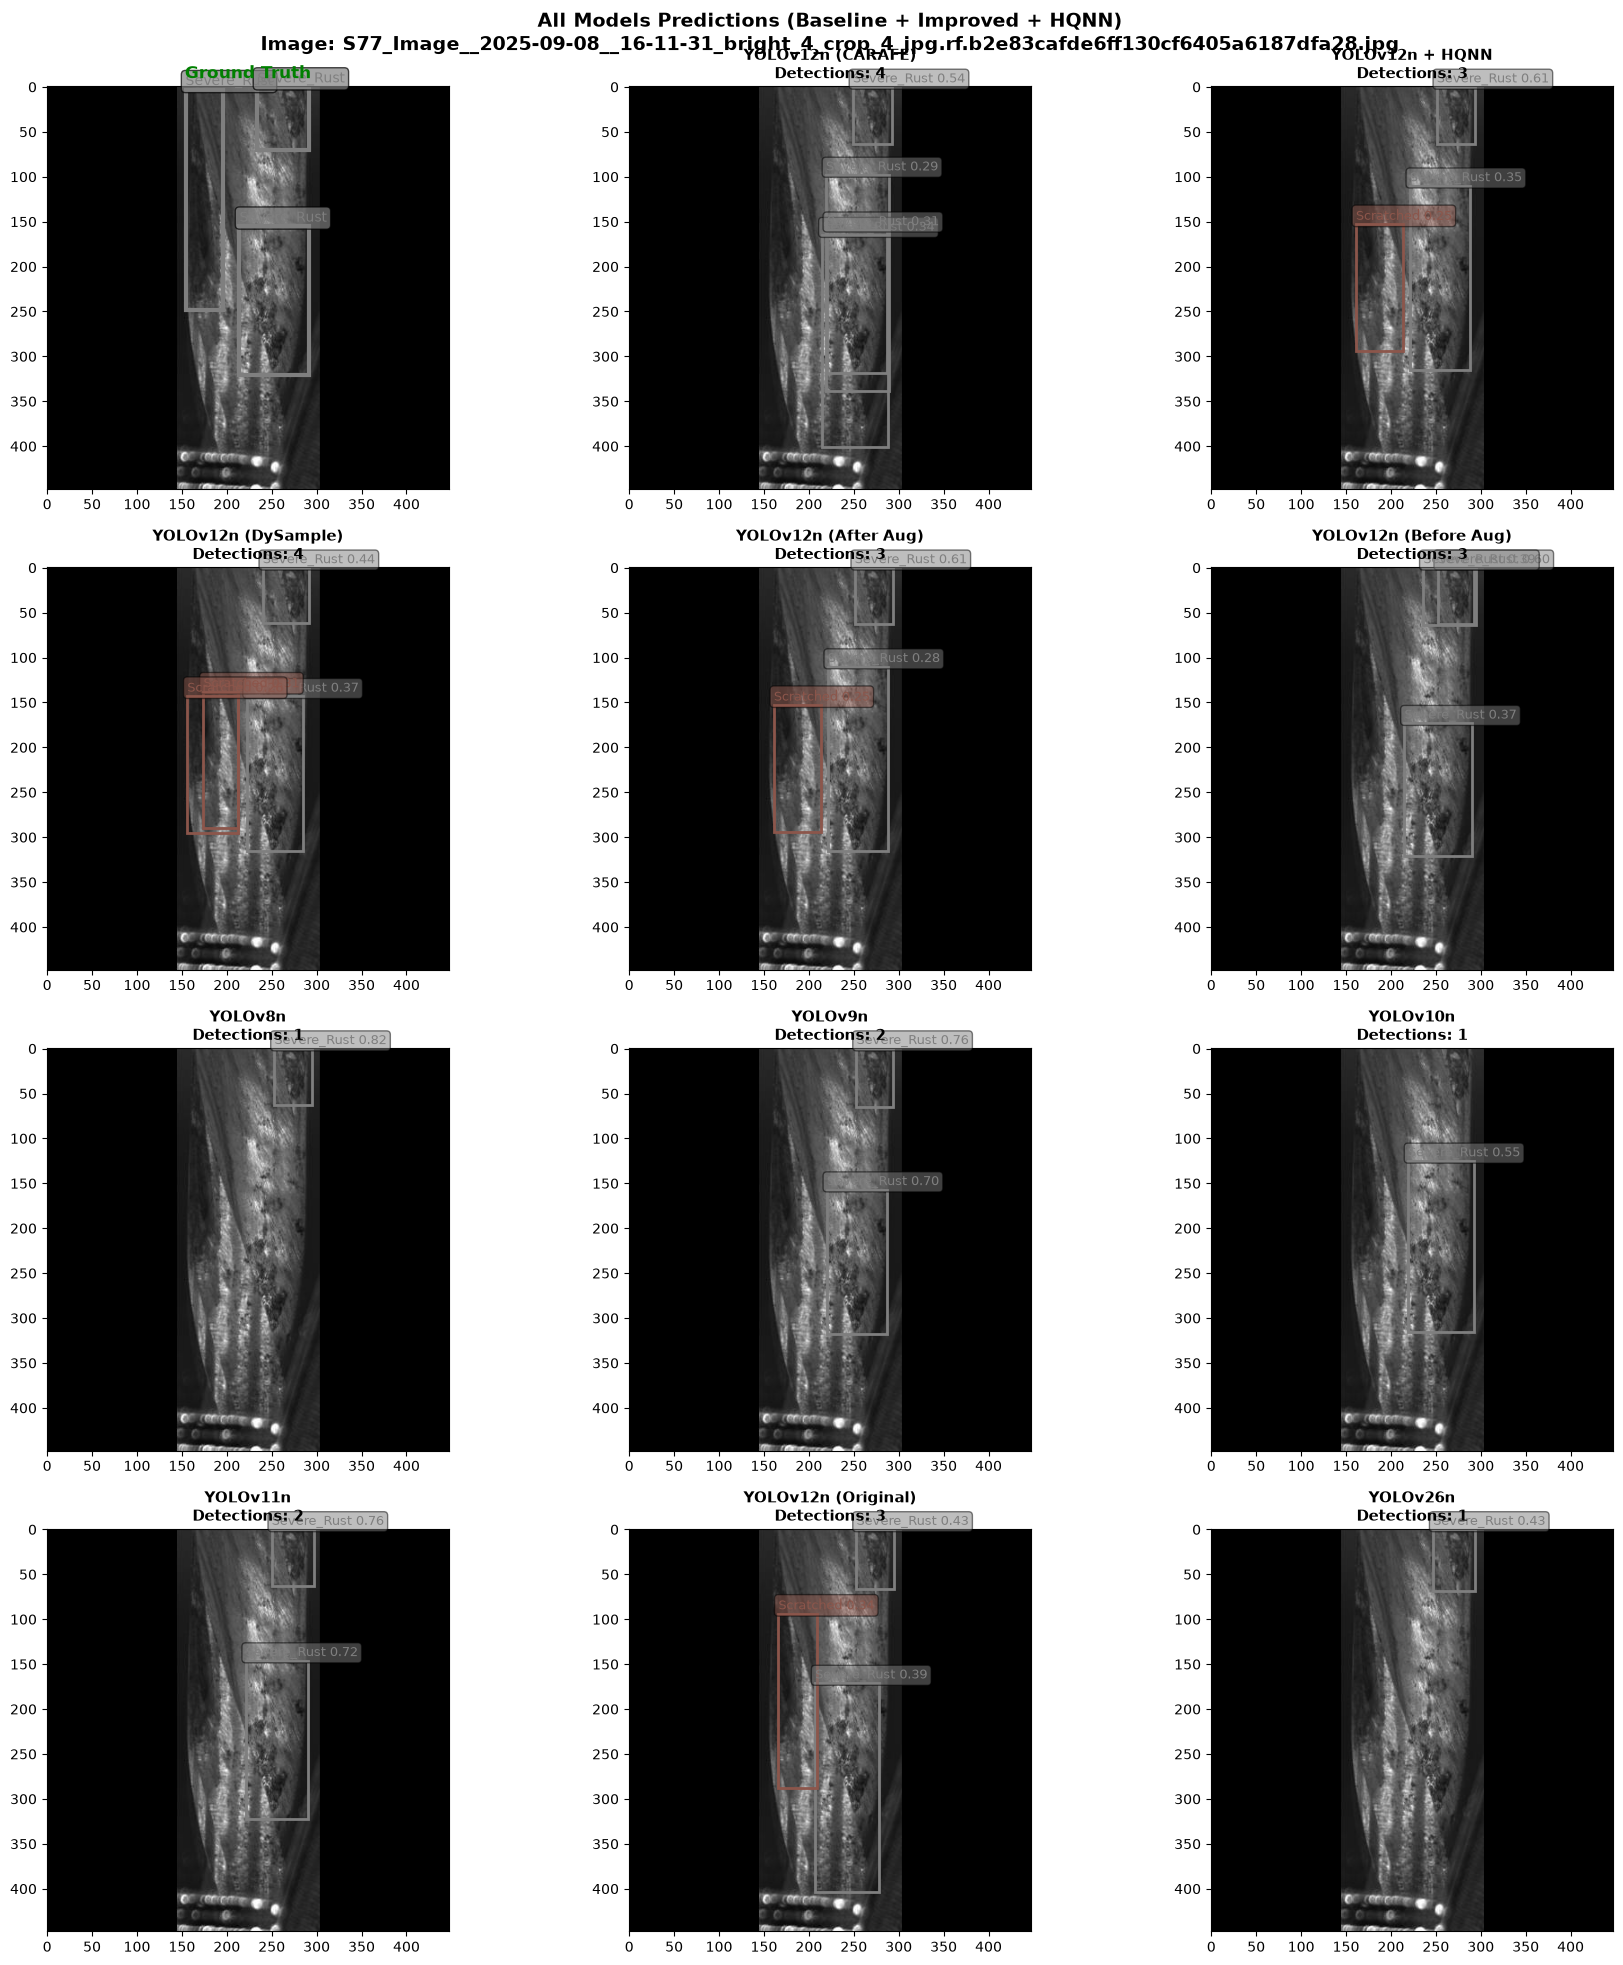


📸 --- Ảnh: S77_Image__2025-09-08__16-11-31_bright_4_crop_4_jpg.rf.b2e83cafde6ff130cf6405a6187dfa28.jpg (HQNN Fusion Details) ---
  Box 1: Final=Severe_Rust(0.61) | YOLO=Severe_Rust(0.61) | Quantum_P_q(Severe_Rust)=0.74
  Box 2: Final=Severe_Rust(0.35) | YOLO=Severe_Rust(0.28) | Quantum_P_q(Severe_Rust)=0.98
  Box 3: Final=Scratched(0.25) | YOLO=Scratched(0.25) | Quantum_P_q(Scratched)=0.55


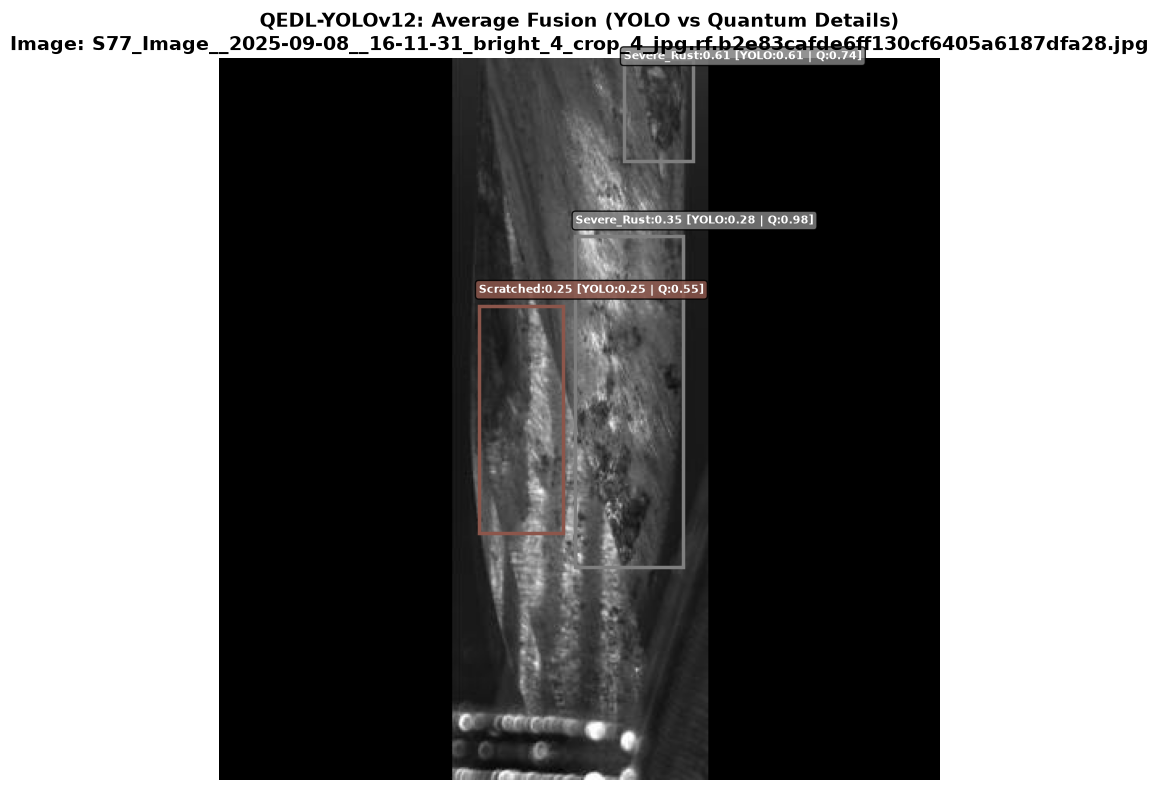

In [902]:
# Chạy lại inference cho ảnh mới đã chọn
label_path = test_label_dir / (img_path.stem + ".txt")
img_bgr = cv2.imread(str(img_path))
h, w = img_bgr.shape[:2]
gt_boxes = load_ground_truth(label_path, w, h)
print(f"Ground Truth: {len(gt_boxes)} objects")

# Baseline predictions cho ảnh mới
baseline_predictions = {}
for model_name, model in baseline_models.items():
    results = model(str(img_path), conf=0.25, device=DEVICE, verbose=False)
    preds = []
    for result in results:
        if result.boxes is None or len(result.boxes) == 0:
            continue
        boxes_xyxy = result.boxes.xyxy.detach().cpu().numpy()
        confs = result.boxes.conf.detach().cpu().numpy()
        cls_ids = result.boxes.cls.detach().cpu().numpy().astype(int)
        for xyxy, conf, cls_id in zip(boxes_xyxy, confs, cls_ids):
            x1, y1, x2, y2 = map(int, xyxy)
            preds.append({"bbox": (x1, y1, x2, y2), "cls_id": int(cls_id), "cls_name": CLASS_NAMES[int(cls_id)], "conf": float(conf)})
    baseline_predictions[model_name] = preds
    print(f"  {model_name}: {len(preds)} detections")

# Improved predictions cho ảnh mới
improved_predictions = {}
for model_name, model in improved_models.items():
    results = model(str(img_path), conf=0.25, device=DEVICE, verbose=False)
    preds = []
    for result in results:
        if result.boxes is None or len(result.boxes) == 0:
            continue
        boxes_xyxy = result.boxes.xyxy.detach().cpu().numpy()
        confs = result.boxes.conf.detach().cpu().numpy()
        cls_ids = result.boxes.cls.detach().cpu().numpy().astype(int)
        for xyxy, conf, cls_id in zip(boxes_xyxy, confs, cls_ids):
            x1, y1, x2, y2 = map(int, xyxy)
            preds.append({"bbox": (x1, y1, x2, y2), "cls_id": int(cls_id), "cls_name": CLASS_NAMES[int(cls_id)], "conf": float(conf)})
    improved_predictions[model_name] = preds
    print(f"  {model_name}: {len(preds)} detections")

# HQNN Fusion cho ảnh mới
if hqnn_model is not None and yolo_for_hqnn is not None:
    print("  YOLOv12n + HQNN: running fusion...")
    detections_hqnn, _ = predict_q_yolo_fusion(yolo_for_hqnn, img_path, conf_thresh=0.25)
    hqnn_preds = []
    for det in detections_hqnn:
        hqnn_preds.append({
            "bbox": det["bbox"],
            "cls_id": det["final_cls"],
            "cls_name": CLASS_NAMES[det["final_cls"]],
            "conf": det["final_conf"]
        })
    improved_predictions["YOLOv12n + HQNN"] = hqnn_preds
    print(f"  YOLOv12n + HQNN: {len(hqnn_preds)} detections")

# Kết hợp tất cả predictions và sắp xếp lại thứ tự
all_predictions = {}
for name, preds in baseline_predictions.items():
    all_predictions[name] = preds
for name, preds in improved_predictions.items():
    if name != "YOLOv12n + HQNN":
        all_predictions[name] = preds

final_predictions = {}
order = ["YOLOv12n (CARAFE)", "YOLOv12n + HQNN", "YOLOv12n (DySample)", "YOLOv12n (After Aug)", "YOLOv12n (Before Aug)", 
         "YOLOv8n", "YOLOv9n", "YOLOv10n", "YOLOv11n", "YOLOv12n (Original)", "YOLOv26n"]
for name in order:
    if name in all_predictions:
        final_predictions[name] = all_predictions[name]
    elif name == "YOLOv12n + HQNN" and name in improved_predictions:
        final_predictions[name] = improved_predictions[name]
for name, preds in all_predictions.items():
    if name not in final_predictions:
        final_predictions[name] = preds

# Hiển thị tất cả
if img_path is not None and final_predictions:
    visualize_predictions(img_path, gt_boxes, final_predictions, title="All Models Predictions (Baseline + Improved + HQNN)")

# In chi tiết kết quả HQNN fusion
if hqnn_model is not None and yolo_for_hqnn is not None and img_path is not None:
    print(f"\n📸 --- Ảnh: {img_path.name} (HQNN Fusion Details) ---")
    detections_hqnn, img_bgr = predict_q_yolo_fusion(yolo_for_hqnn, img_path, conf_thresh=0.25)
    if img_bgr is not None and len(detections_hqnn) > 0:
        import matplotlib.pyplot as plt
        import matplotlib.patches as patches
        import cv2
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        fig, ax = plt.subplots(1, 1, figsize=(12, 8))
        ax.imshow(img_rgb)
        ax.set_title(f"QEDL-YOLOv12: Average Fusion (YOLO vs Quantum Details)\nImage: {img_path.name}", fontsize=14, fontweight='bold')
        for b_idx, det in enumerate(detections_hqnn, 1):
            x1, y1, x2, y2 = det["bbox"]
            fc = det["final_cls"]
            conf = det["final_conf"]
            color = COLORS[fc % len(COLORS)][:3]
            p_yolo_val = det["yolo_conf"]
            p_quant_val = det["p_quantum"][fc]
            yolo_name = CLASS_NAMES[det["yolo_cls"]]
            final_name = CLASS_NAMES[fc]
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2.5, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            if det["yolo_cls"] != fc:
                tag = f"{final_name}:{conf:.2f} [YOLO:{yolo_name}({p_yolo_val:.2f}) | Q:{p_quant_val:.2f}]"
            else:
                tag = f"{final_name}:{conf:.2f} [YOLO:{p_yolo_val:.2f} | Q:{p_quant_val:.2f}]"
            ax.text(x1, max(0, y1 - 8), tag, bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.85),
                    fontsize=8, color="white", fontweight="bold")
            print(f"  Box {b_idx}: Final={final_name}({conf:.2f}) | YOLO={yolo_name}({p_yolo_val:.2f}) | Quantum_P_q({final_name})={p_quant_val:.2f}")
        ax.axis('off')
        plt.tight_layout()
        plt.show()
    elif len(detections_hqnn) == 0:
        print("  No detections from HQNN fusion.")